# LeetCode #617: Merge Two Binary Trees

https://leetcode.com/problems/merge-two-binary-trees/

## Comparison of Approaches

| Approach | Time Complexity | Space Complexity |
| :--- | :--- | :--- |
| **Iterative (queue-based BFS)** | $O(n)$ | $O(n)$ |
| **Optimal: DFS Recursive Merge ★** | $O(n)$ | $O(h)$ |

---

## Understanding the Methods

### Iterative (queue-based BFS)
Use a queue of paired nodes from both trees. At each step, sum values and enqueue children pairs. Requires $O(n)$ space for the queue.

### Optimal: DFS Recursive Merge ★
If either node is null, return the other (no merge needed). Otherwise, add `root2.val` into `root1.val` in-place, then recursively merge left and right children. Space is $O(h)$ for the recursion stack (height of the merged tree).

**Why this is better than Iterative:** Recursion uses $O(h)$ stack space vs. $O(n)$ queue space, and the in-place merge eliminates extra node allocation.

**Constraints:**
* The number of nodes in both trees is in the range $[0, 2000]$
* $-10^4 \le \text{Node.val} \le 10^4$


## Solutions

### C#

In [ ]:
public TreeNode MergeTrees(TreeNode root1, TreeNode root2) {
    // If either node is absent, the other tree takes its place
    if (root1 == null) return root2;
    if (root2 == null) return root1;
    // Sum overlapping nodes in-place and recurse on both children
    root1.val += root2.val;
    root1.left  = MergeTrees(root1.left,  root2.left);
    root1.right = MergeTrees(root1.right, root2.right);
    return root1;
}

### Python

In [ ]:
def merge_trees(root1, root2):
    # If either node is absent, the other tree takes its place
    if not root1:
        return root2
    if not root2:
        return root1
    # Sum overlapping nodes in-place and recurse on both children
    root1.val += root2.val
    root1.left  = merge_trees(root1.left,  root2.left)
    root1.right = merge_trees(root1.right, root2.right)
    return root1

### Go

In [ ]:
func mergeTrees(root1 *TreeNode, root2 *TreeNode) *TreeNode {
    // If either node is absent, the other tree takes its place
    if root1 == nil { return root2 }
    if root2 == nil { return root1 }
    // Sum overlapping nodes in-place and recurse on both children
    root1.Val += root2.Val
    root1.Left  = mergeTrees(root1.Left,  root2.Left)
    root1.Right = mergeTrees(root1.Right, root2.Right)
    return root1
}

### Rust

In [ ]:
pub fn merge_trees(
    root1: Option<Box<TreeNode>>,
    root2: Option<Box<TreeNode>>,
) -> Option<Box<TreeNode>> {
    match (root1, root2) {
        // If either node is absent, the other tree takes its place
        (None, r) => r,
        (l, None) => l,
        (Some(mut n1), Some(n2)) => {
            // Sum overlapping nodes in-place and recurse on both children
            n1.val += n2.val;
            n1.left  = Self::merge_trees(n1.left.take(),  n2.left);
            n1.right = Self::merge_trees(n1.right.take(), n2.right);
            Some(n1)
        }
    }
}

## Example Scenarios

**1. Common Case**
**Input:** `root1 = [1,3,2,5]`, `root2 = [2,1,3,null,4,null,7]`
Root: 1+2=3. Left: 3+1=4, left-left: 5+null=5, left-right: null+4=4. Right: 2+3=5, right-right: null+7=7. Result: [3,4,5,5,4,null,7].

**2. Slightly Complex**
**Input:** `root1 = [1]`, `root2 = [1,2]`
Root: 1+1=2. Right: null+2=2 (taken from root2). Left: null+null=null. Result: [2,null,2].

**3. Edge Case: Time Factor**
**Input:** Two complete balanced trees of height $h$ ($n \approx 2^h$ nodes each)
Every node in the smaller tree is visited. All overlapping nodes are merged; non-overlapping subtrees are attached as-is. Total: $O(\min(n_1, n_2))$ visits required in the worst case (fully overlapping trees).

**4. Edge Case: Space Factor**
**Input:** Right-skewed trees of height $h = 2000$
Recursion depth = $h$. Stack holds $O(h)$ frames — at $h=2000$, well within typical stack limits. Queue-based BFS would need $O(n)$ space instead.

**5. Almost-Impossible but Plausible**
**Input:** `root1 = [-10000]`, `root2 = [-10000]`
Root values: $-10000 + (-10000) = -20000$. This exceeds the node value range $[-10^4, 10^4]$ but the merged tree still holds it correctly as an `int`. Edge case: sum of two boundary values.


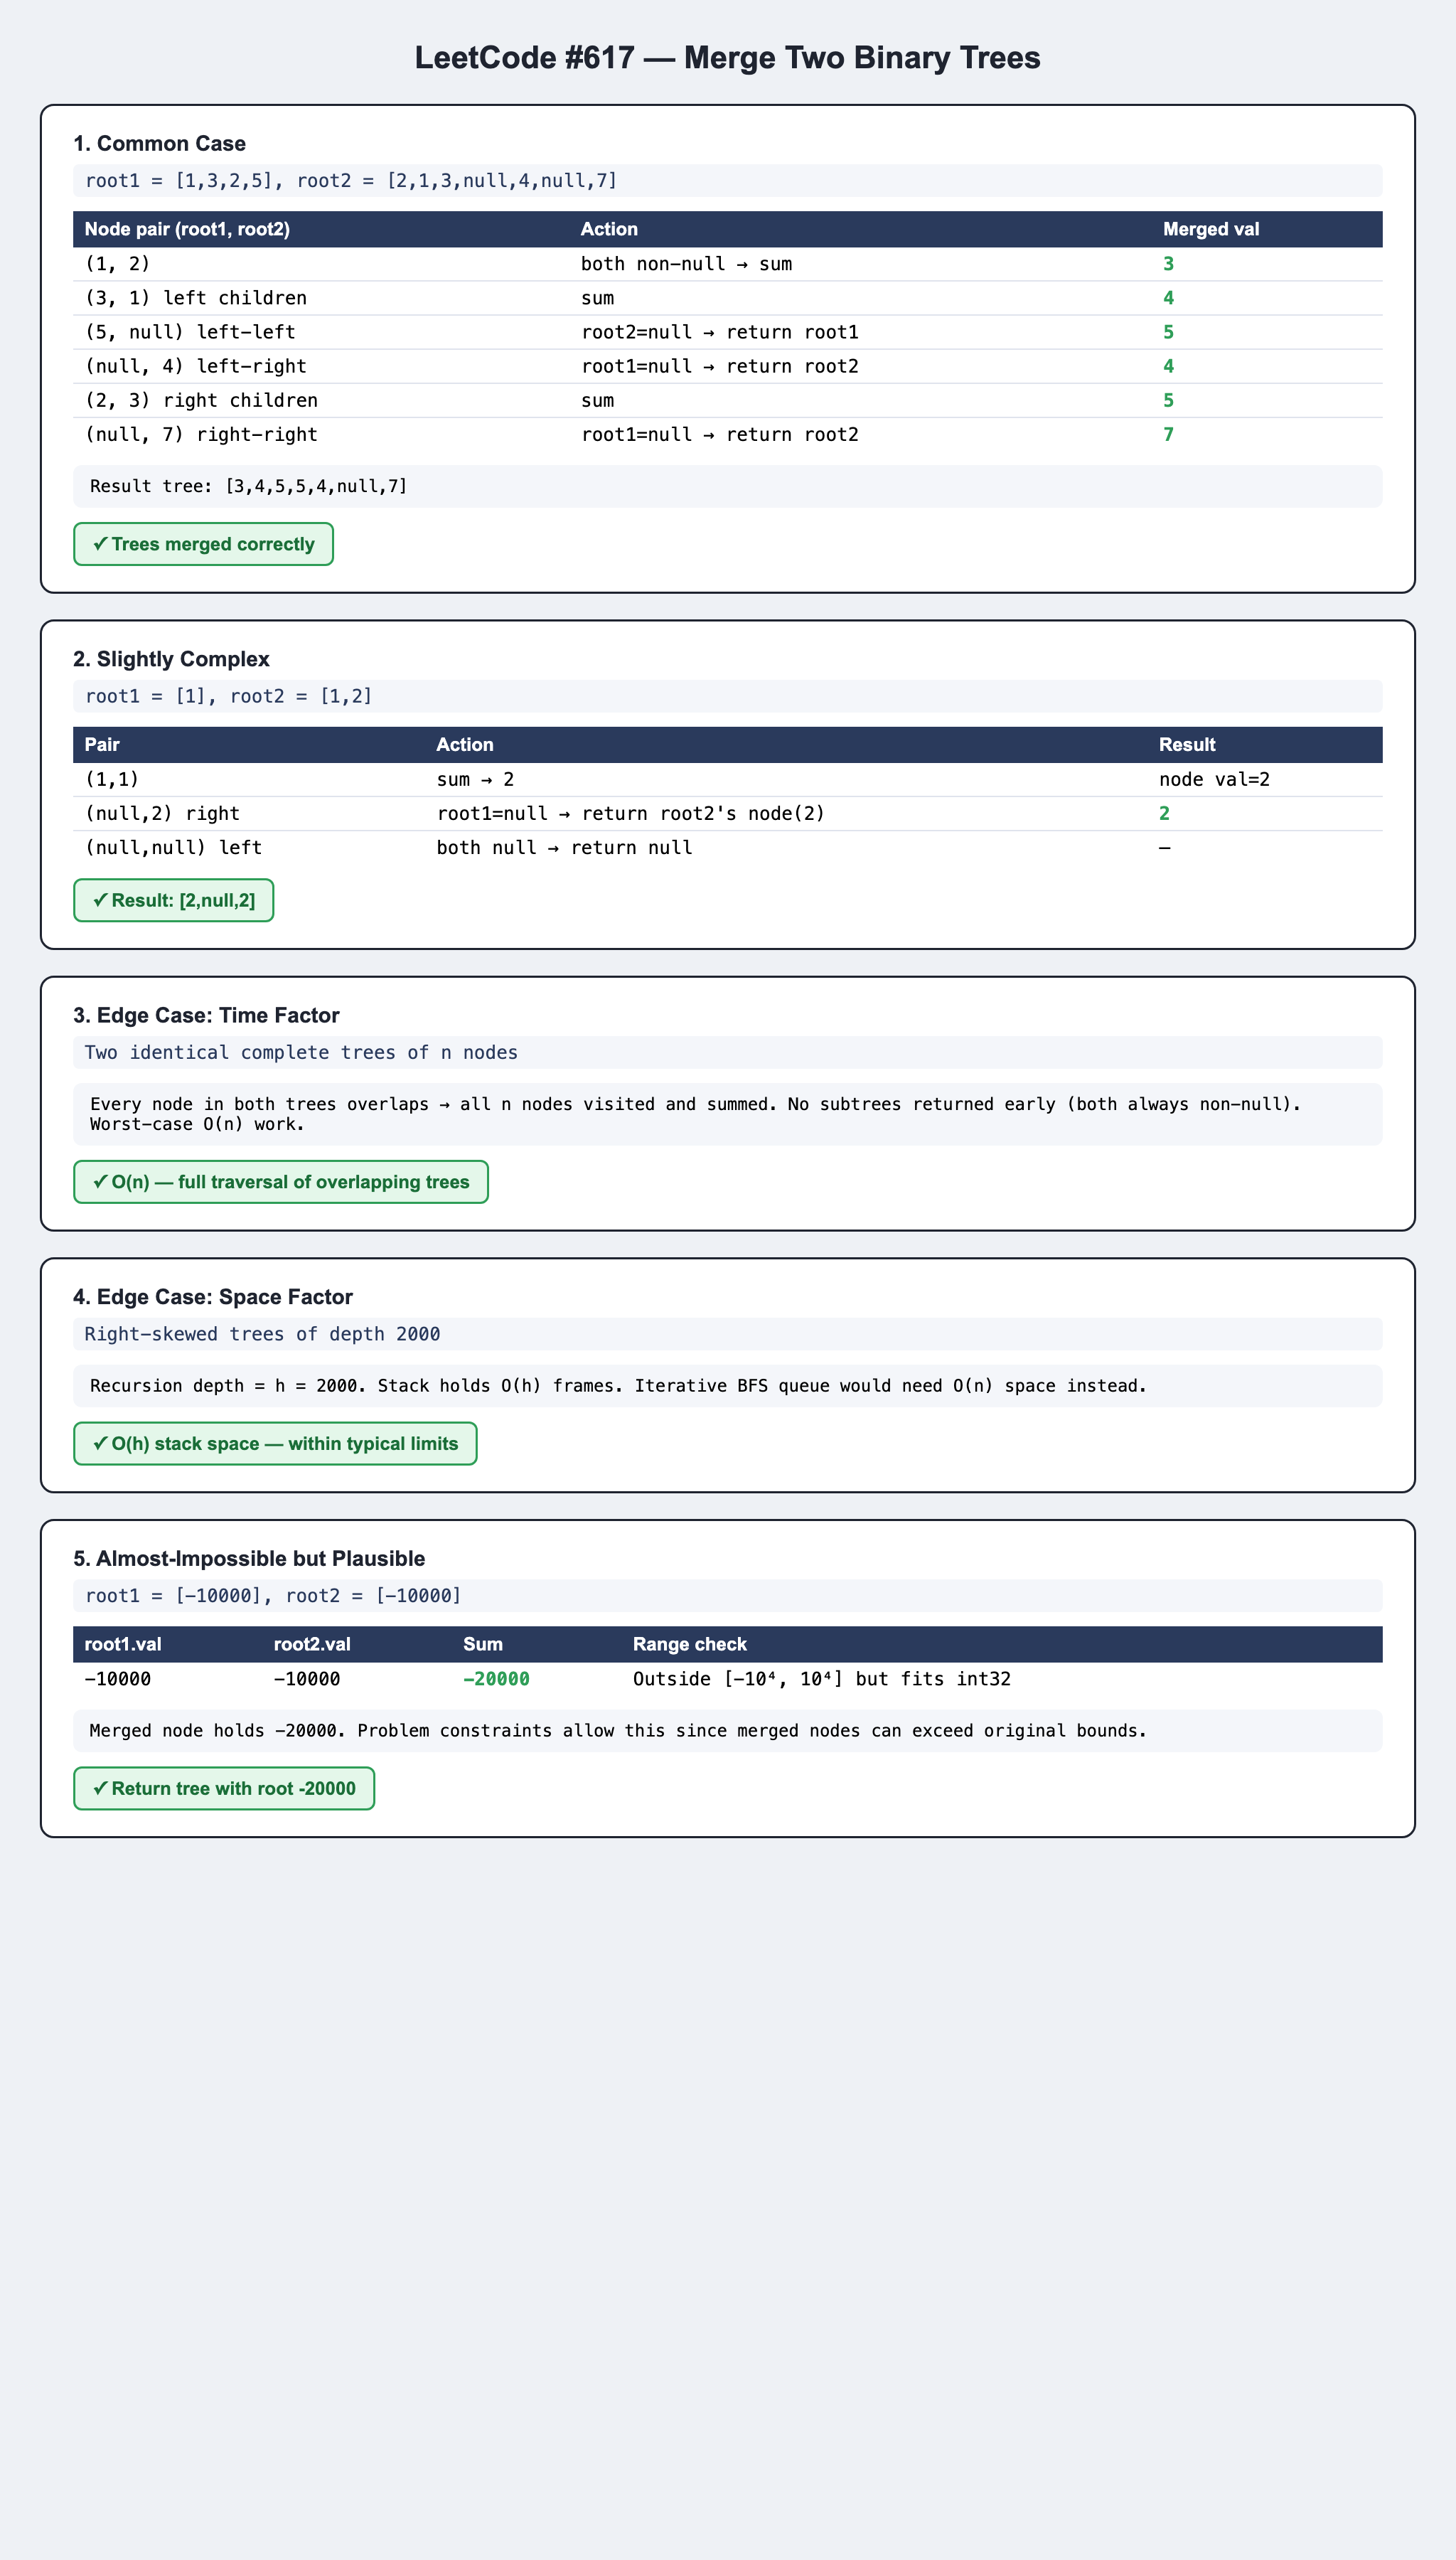